In [1]:
%pip install plotly ipython

Note: you may need to restart the kernel to use updated packages.


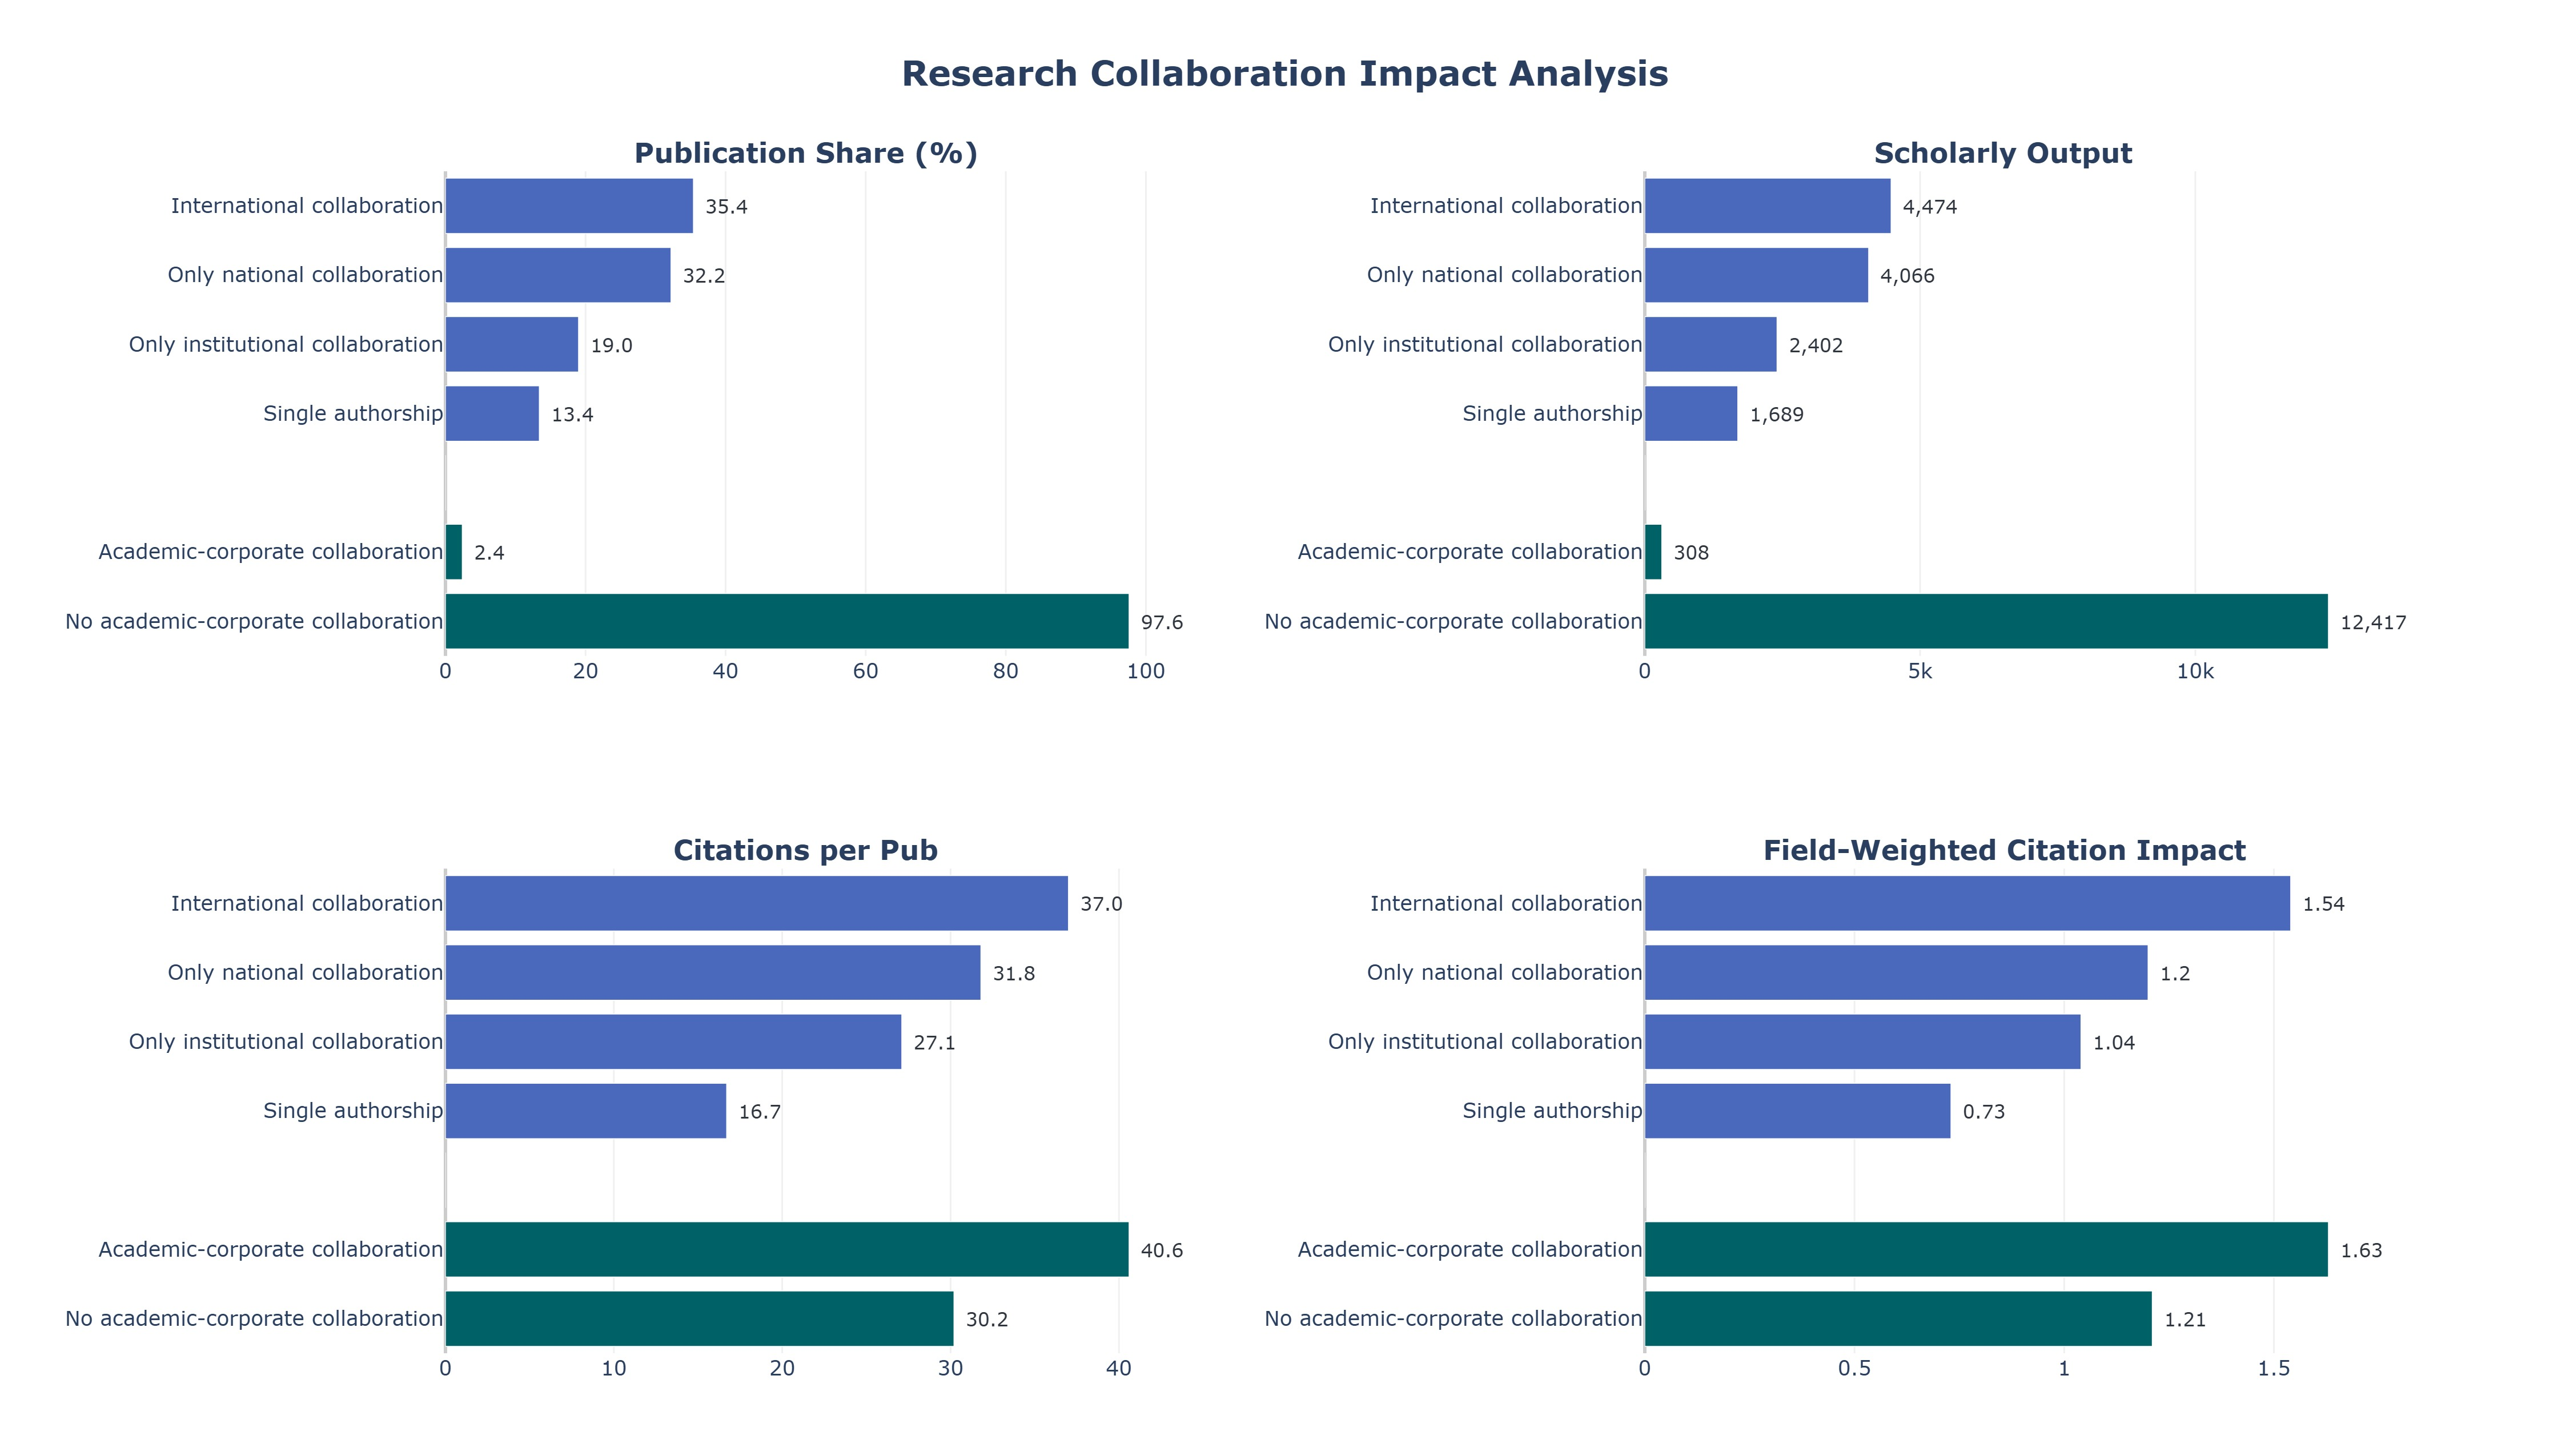

In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Image, display

# Combined Data from both images
categories = [
    "International collaboration",
    "Only national collaboration",
    "Only institutional collaboration",
    "Single authorship",
    " ", # Visual separator (blank space)
    "Academic-corporate collaboration",
    "No academic-corporate collaboration"
]

data = {
    "Publication Share (%)": [35.4, 32.2, 19.0, 13.4, 0, 2.4, 97.6],
    "Scholarly Output": [4474, 4066, 2402, 1689, 0, 308, 12417],
    "Citations per Pub": [37.0, 31.8, 27.1, 16.7, 0, 40.6, 30.2],
    "Field-Weighted Citation Impact": [1.54, 1.20, 1.04, 0.73, 0, 1.63, 1.21]
}

# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"<b>{k}</b>" for k in data.keys()],
    horizontal_spacing=0.25,
    vertical_spacing=0.18,
    column_widths=[0.50, 0.50]
)

# Colors
colors = [
    '#4A69BD', '#4A69BD', '#4A69BD', '#4A69BD', 
    'rgba(0,0,0,0)', 
    '#006266', '#006266'
]

# Add traces
for i, (metric, values) in enumerate(data.items()):
    row = (i // 2) + 1
    col = (i % 2) + 1
    text_labels = [f" {v:,}" if v > 0 else "" for v in values]
    
    fig.add_trace(
        go.Bar(
            y=categories,
            x=values,
            orientation='h',
            marker_color=colors,
            text=text_labels,
            textposition='outside',
            textfont=dict(size=11, color='#2f3640'),
            cliponaxis=False,
            name=metric,
            showlegend=False
        ),
        row=row, col=col
    )

# Layout
fig.update_layout(
    title_text="<b>Research Collaboration Impact Analysis</b>",
    title_x=0.5,
    title_font=dict(size=20),
    height=850,
    width=1500,
    template="plotly_white",
    margin=dict(l=260, r=120, t=100, b=60)
)

fig.update_yaxes(autorange="reversed", tickfont=dict(size=12))
fig.update_xaxes(showgrid=True, gridcolor='#F0F0F0', zeroline=True, zerolinecolor='#CCCCCC')

# --- DISPLAY ONLY ---
# This converts the figure to a high-res JPG and stores it INSIDE the notebook file.
img_bytes = fig.to_image(format="jpg", width=1500, height=850, scale=3)
display(Image(img_bytes))

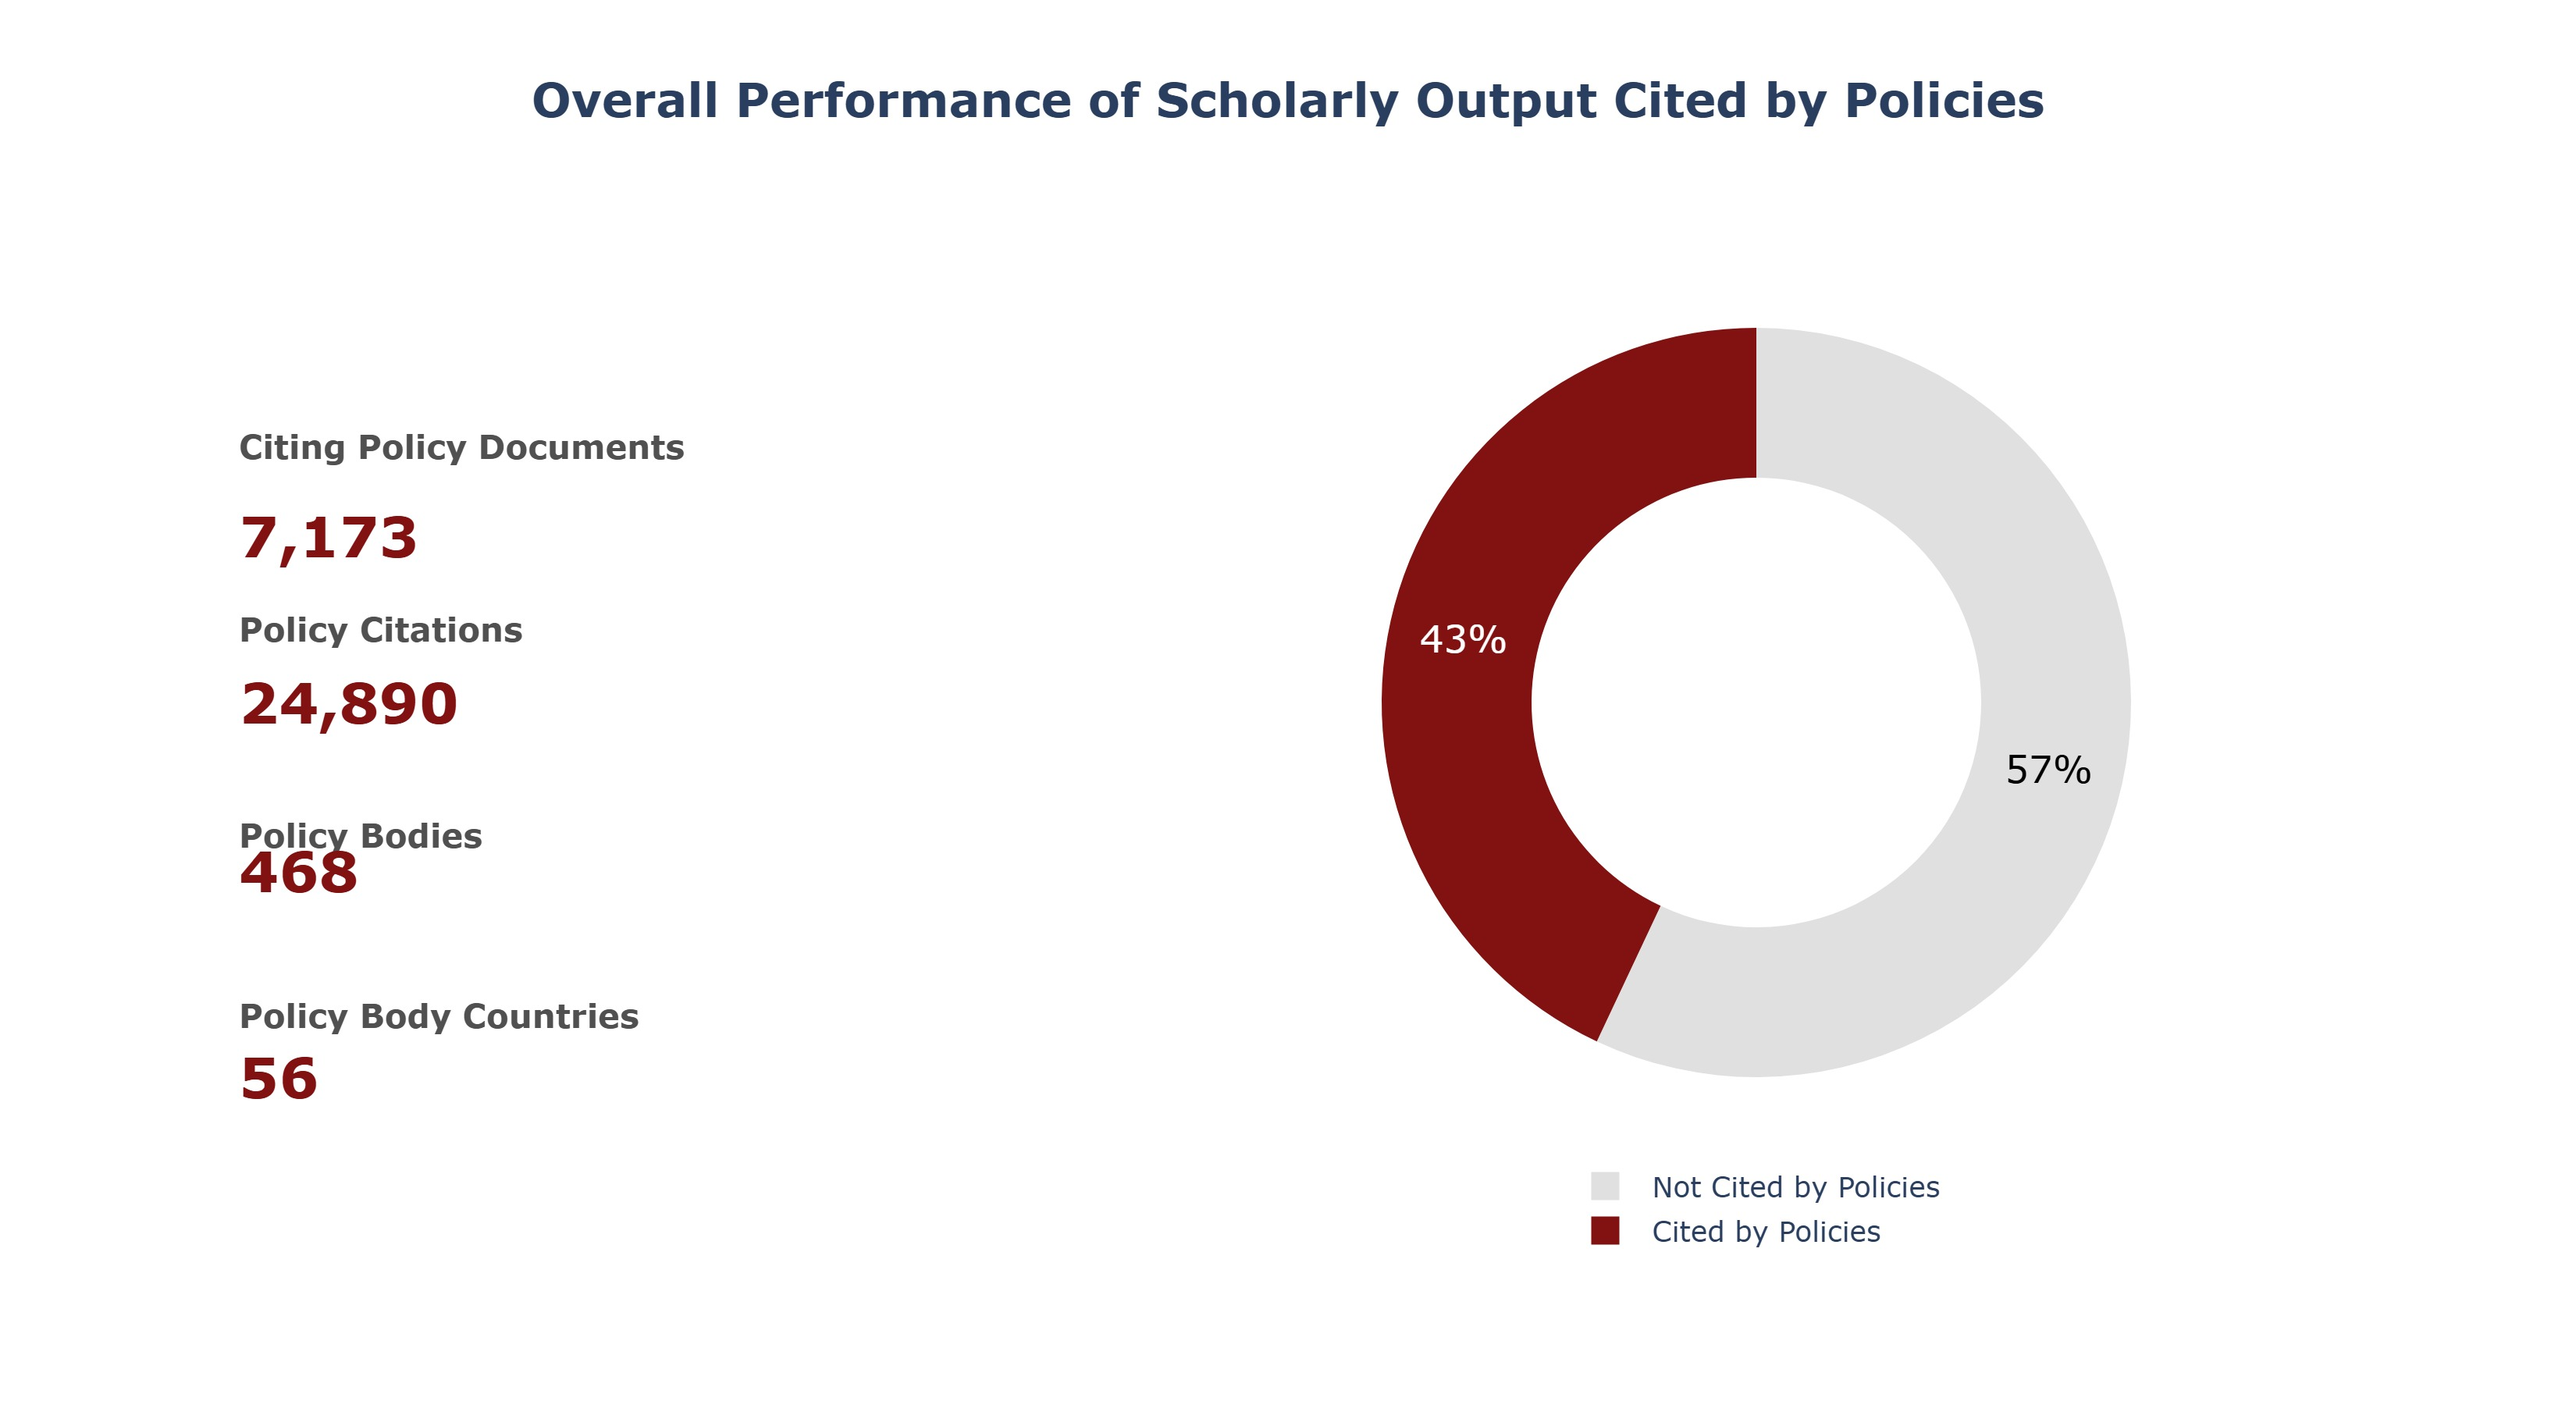

In [ ]:
import plotly.graph_objects as go
from IPython.display import Image, display

# Data
policy_coverage_val = 5129
total_scholarly_output_est = 11928 
other_output = total_scholarly_output_est - policy_coverage_val

metrics = {
    "Citing Policy Documents": "7,173",
    "Policy Citations": "24,890",
    "Policy Bodies": "468",
    "Policy Body Countries": "56"
}

def get_contrasting_text_color(hex_color):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    luminance = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    return '#FFFFFF' if luminance < 0.5 else '#000000'

marker_colors = ['#821111', '#E0E0E0']
text_colors = [get_contrasting_text_color(color) for color in marker_colors]

fig = go.Figure()

# Donut Chart
fig.add_trace(go.Pie(
    labels=["Cited by Policies", "Not Cited by Policies"],
    values=[policy_coverage_val, other_output],
    hole=0.6,
    marker=dict(colors=marker_colors),
    textinfo='percent',
    textfont=dict(size=16, color=text_colors),
    domain={'x': [0.45, 0.95], 'y': [0.1, 0.9]}, 
    showlegend=True,
    legendgroup="coverage"
))

# Annotations
y_pos = 0.8
for label, value in metrics.items():
    fig.add_annotation(
        x=0.05, y=y_pos,
        text=f"<b>{label}</b>",
        showarrow=False,
        font=dict(size=14, color="#505050"),
        xref="paper", yref="paper",
        xanchor="left"
    )
    fig.add_annotation(
        x=0.05, y=y_pos - 0.08,
        text=f"<span style='color:#821111; font-size:24px'><b>{value}</b></span>",
        showarrow=False,
        xref="paper", yref="paper",
        xanchor="left"
    )
    y_pos -= 0.22 

# Layout
fig.update_layout(
    title_text="<b>Overall Performance of Scholarly Output Cited by Policies</b>",
    title_x=0.5,
    title_font=dict(size=20),
    height=600,
    width=1100,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.7),
    margin=dict(l=50, r=50, t=100, b=100)
)

# --- DISPLAY ONLY ---
# This converts the figure to a high-res JPG and stores it INSIDE the notebook file.
img_bytes = fig.to_image(format="jpg", width=1100, height=600, scale=3)
display(Image(img_bytes))


